<a href="https://colab.research.google.com/github/LonelyDreamer005/wellbeingAnalysis/blob/main/cbp_DE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# load dataset
b = pd.read_csv('/content/ScreenTime vs MentalWellness.csv')

# preview
print(b.head())
print(b.info())

  user_id  age  gender occupation  work_mode  screen_time_hours  \
0   U0001   33  Female   Employed     Remote              10.79   
1   U0002   28  Female   Employed  In-person               7.40   
2   U0003   35  Female   Employed     Hybrid               9.78   
3   U0004   42    Male   Employed     Hybrid              11.13   
4   U0005   28    Male    Student     Remote              13.22   

   work_screen_hours  leisure_screen_hours  sleep_hours  sleep_quality_1_5  \
0               5.44                  5.35         6.63                  1   
1               0.37                  7.03         8.05                  3   
2               1.09                  8.69         6.48                  1   
3               0.56                 10.57         6.89                  1   
4               4.09                  9.13         5.79                  1   

   stress_level_0_10  productivity_0_100  exercise_minutes_per_week  \
0                9.3                44.7                 

In [ ]:
# check missing values
c = b.isnull().sum()
print("Missing values:\n", c)

# check duplicate rows
e = b.duplicated().sum()
print("Duplicate rows:", e)

# basic stats
print(b.describe())

Missing values:
 user_id                          0
age                              0
gender                           0
occupation                       0
work_mode                        0
screen_time_hours                0
work_screen_hours                0
leisure_screen_hours             0
sleep_hours                      0
sleep_quality_1_5                0
stress_level_0_10                0
productivity_0_100               0
exercise_minutes_per_week        0
social_hours_per_week            0
mental_wellness_index_0_100      0
Unnamed: 15                    400
Unnamed: 16                    400
Perfection Level               400
dtype: int64
Duplicate rows: 0
             age  screen_time_hours  work_screen_hours  leisure_screen_hours  \
count  400.00000         400.000000         400.000000            400.000000   
mean    29.77750           9.024900           2.183075              6.841825   
std      7.46608           2.491058           1.931321              2.220896   
mi

In [ ]:
# drop user_id if present
if 'user_id' in b.columns:
    b.drop(columns=['user_id'], inplace=True)

# drop completely null columns (e.g., Unnamed columns)
g = [k for k in b.columns if b[k].isnull().all()]
b.drop(columns=g, inplace=True)

# remove duplicate rows if any
b.drop_duplicates(inplace=True)

print("Columns after cleaning:", b.columns)

Columns after cleaning: Index(['age', 'gender', 'occupation', 'work_mode', 'screen_time_hours',
       'work_screen_hours', 'leisure_screen_hours', 'sleep_hours',
       'sleep_quality_1_5', 'stress_level_0_10', 'productivity_0_100',
       'exercise_minutes_per_week', 'social_hours_per_week',
       'mental_wellness_index_0_100'],
      dtype='object')


In [ ]:
# check if total screen time equals work + leisure
if set(['screen_time_hours','work_screen_hours','leisure_screen_hours']).issubset(b.columns):
    b['screen_time_check'] = b['work_screen_hours'] + b['leisure_screen_hours']

# difference to detect inconsistencies
if 'screen_time_check' in b.columns:
    b['screen_time_diff'] = b['screen_time_hours'] - b['screen_time_check']

print(b[['screen_time_hours','work_screen_hours','leisure_screen_hours','screen_time_diff']].head())

   screen_time_hours  work_screen_hours  leisure_screen_hours  \
0              10.79               5.44                  5.35   
1               7.40               0.37                  7.03   
2               9.78               1.09                  8.69   
3              11.13               0.56                 10.57   
4              13.22               4.09                  9.13   

   screen_time_diff  
0               0.0  
1               0.0  
2               0.0  
3               0.0  
4               0.0  


In [ ]:
# identify categorical columns
m = b.select_dtypes(include=['object']).columns
print("Categorical columns:", list(m))

# label encoding (simple)
for q in m:
    b[q] = b[q].astype('category').cat.codes

Categorical columns: ['gender', 'occupation', 'work_mode']


In [ ]:
# clip values to valid ranges to remove entry errors
if 'stress_level' in b.columns:
    b['stress_level'] = b['stress_level'].clip(0, 10)

if 'sleep_quality' in b.columns:
    b['sleep_quality'] = b['sleep_quality'].clip(1, 5)

if 'mental_wellness_index' in b.columns:
    b['mental_wellness_index'] = b['mental_wellness_index'].clip(0, 100)

if 'productivity' in b.columns:
    b['productivity'] = b['productivity'].clip(0, 100)

In [ ]:
# final cleaned dataset
s = b.copy()
print("Final shape:", s.shape)
s.head()

Final shape: (400, 16)


,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,screen_time_check,screen_time_diff
0,33,0,0,2,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3,10.79,0.0
1,28,0,0,1,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2,7.40,0.0
2,35,0,0,0,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6,9.78,0.0
3,42,1,0,0,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0,11.13,0.0
4,28,1,3,2,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0,13.22,0.0


In [ ]:
# save cleaned dataset
s.to_csv('/content/refined_screen_time_dataset.csv', index=False)
print("Exported successfully!")

Exported successfully!


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
file_path = '/content/refined_screen_time_dataset.csv'   # adjust path if needed
df = pd.read_csv(file_path)

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

In [ ]:
correlation_matrix = numeric_df.corr()

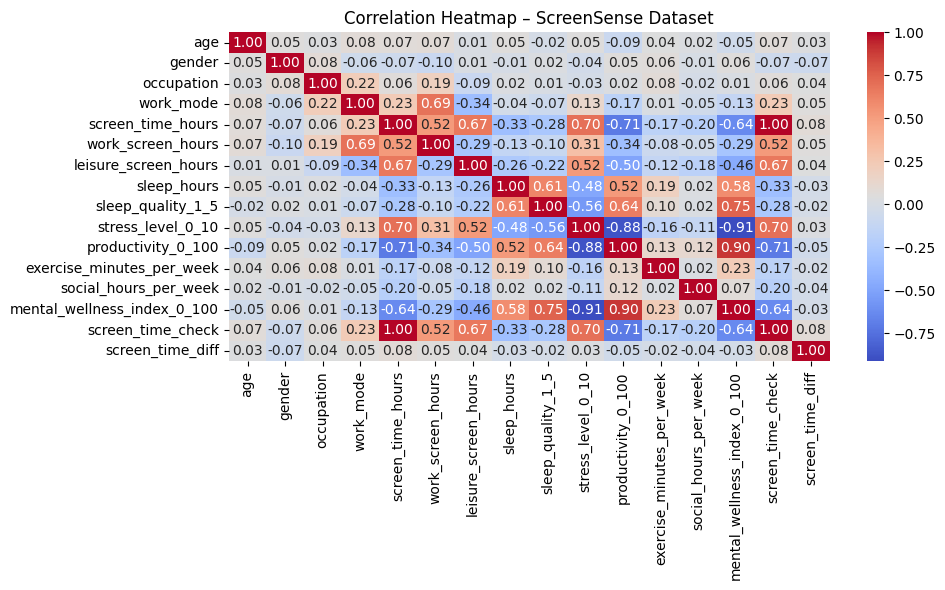

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap – ScreenSense Dataset')
plt.tight_layout()
plt.show()